# 🚨 THE 20-MINUTE SPRINT 🚨 - PES2UG24CS461
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [ ]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("apple_products_pricing_2020_2026.csv", parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


⏱️  MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.


In [8]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.0 min   |   Remaining: 20.0 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type | Channel |
|---|---|---|
| Current_Price_USD | Continuous quantitative | y-position (bar length) / x-position |
| Product_Category | Unordered qualitative (categorical) | Hue (color) & y-axis grouping |
| Date | Ordered quantitative (temporal) | x-position (line chart) |
| Reviews_Count | Continuous quantitative | Size (bubble area) |
| Rating | Continuous quantitative | x-position |

**Rule check:** every continuous variable above is mapped to a channel that can represent
continuous values (position or size). The single categorical variable (Product_Category)
is the only one on hue — never on shape or dash pattern.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


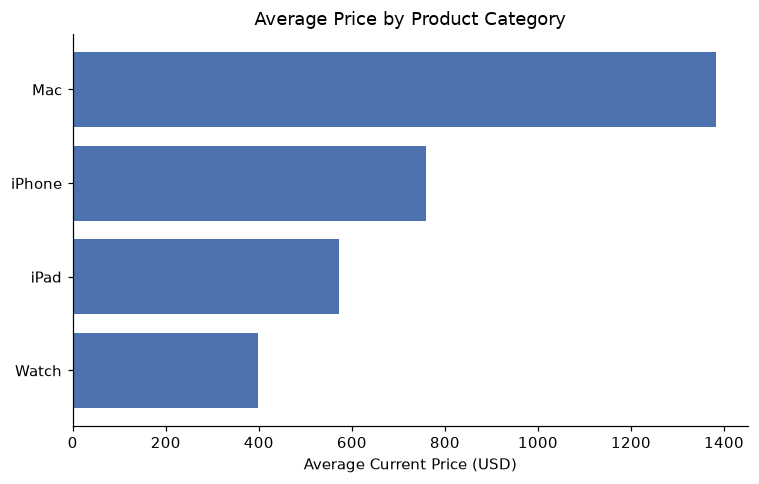

In [9]:
# Compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

# Horizontal bar chart
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# Enforce zero-baseline rule (Proportional Ink)
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()


---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


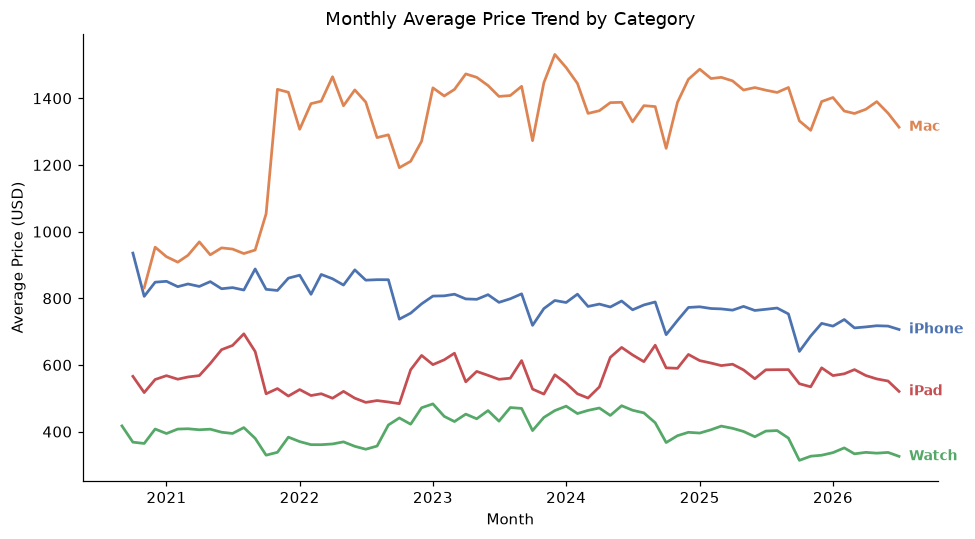

In [10]:
# Compare all four categories monthly
categories_to_plot = ["iPhone", "Mac", "iPad", "Watch"]

fig, ax = plt.subplots(figsize=(9, 5))
palette = {"iPhone": "#4C72B0", "Mac": "#DD8452", "iPad": "#C44E52", "Watch": "#55A868"}

for cat in categories_to_plot:
    monthly = (df[df["Product_Category"] == cat]
               .set_index("Date")
               .resample("MS")["Current_Price_USD"]
               .mean())
    ax.plot(monthly.index, monthly.values, linewidth=1.8, color=palette[cat])
    # Direct end-of-line label (Slide 13)
    ax.text(monthly.index[-1], monthly.values[-1], "  " + cat,
            va="center", color=palette[cat], fontsize=9, fontweight="bold")

ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend by Category")
plt.tight_layout()
plt.show()


---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


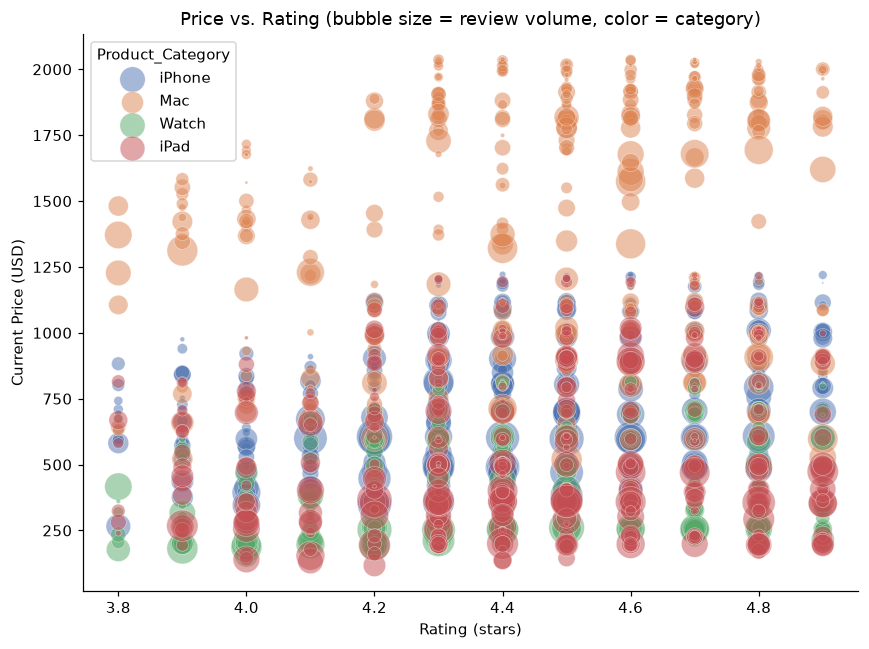

In [5]:
# 3+ variable bubble chart:
#   x = Rating (continuous -> position)
#   y = Current_Price_USD (continuous -> position)
#   size = Reviews_Count (continuous -> size)
#   color = Product_Category (categorical -> hue)
sample = df.sample(2000, random_state=1)

cat_color = {"iPhone": "#4C72B0", "Mac": "#DD8452", "Watch": "#55A868", "iPad": "#C44E52"}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]
    ax.scatter(
        d["Rating"],
        d["Current_Price_USD"],
        s=d["Reviews_Count"] / 20,
        color=color,
        alpha=0.5, edgecolor="white", linewidth=0.4, label=cat
    )

ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (bubble size = review volume, color = category)")
ax.legend(title="Product_Category")
plt.tight_layout()
plt.show()


---
## Task 5 — The Submission Audit *(~2 min)*

- [x] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) — not shape or dash pattern.
- [x] Every bar chart's axis starts at zero.
- [x] Every filled area chart's baseline starts at zero (or I didn't fill any areas —
      I did not fill any areas).
- [x] My time-series uses lines to show chronological order, not disconnected points.
- [x] If two charts show the same variable (Current_Price_USD), the scales are
      consistent (USD, zero-based where appropriate).
- [x] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [6]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 0.0 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## 🪞 Reflection

**1. Time pressure and technique.** The principle I found easiest to overlook under
pressure was **proportional ink / zero baselines** in the bar chart. It was not a lack of
understanding; matplotlib makes it convenient to accept its automatic axis limits and call
`show()` immediately. Without `ax.set_xlim(left=0)`, however, modest price differences can
look much more dramatic than they really are, which could mislead leadership at a glance.

**2. Spot the near-miss.** For Task 4, I briefly considered assigning each
`Product_Category` a different marker shape (`o`, `s`, `^`, `D`) so that I could reduce the
number of colors. That would still have represented the categorical variable correctly,
but I also thought about grouping `Rating` into shapes. That would have been inappropriate
because Rating is continuous. Keeping Rating on a positional channel followed the rule:
continuous data should use position, size, or intensity rather than shape.

**3. The cost of dishonest ink.** If the category-price bar chart used a shortened axis, the
roughly $200 difference between iPad and Mac could appear several times larger. A viewer
might interpret that visual exaggeration as a major performance gap and recommend shifting
marketing resources or changing iPad prices, even though the raw averages do not justify
such a strong conclusion.

**4. Trade-offs under constraint.** Given two hours, I would redesign Task 3 with **small
multiples**, using one panel for each category and the same y-axis across panels. This would
make the trends easier to compare and leave room to annotate important product launches
behind the major jumps. For Task 4, I would also add a clear size legend so the meaning of
`Reviews_Count` is not left for the audience to estimate.

**5. Beyond the classroom.** A similar choice appears when a **quant trader** prepares a
daily P&L or risk dashboard for portfolio managers before a morning meeting. The charts may
need to be produced quickly, but I would still protect honest axes and baselines above all
else. A distorted chart could make a temporary move seem like a lasting trend and encourage
someone to increase a position based on the wrong visual impression.